In [43]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

In [44]:
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [45]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [46]:
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [47]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [48]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [49]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


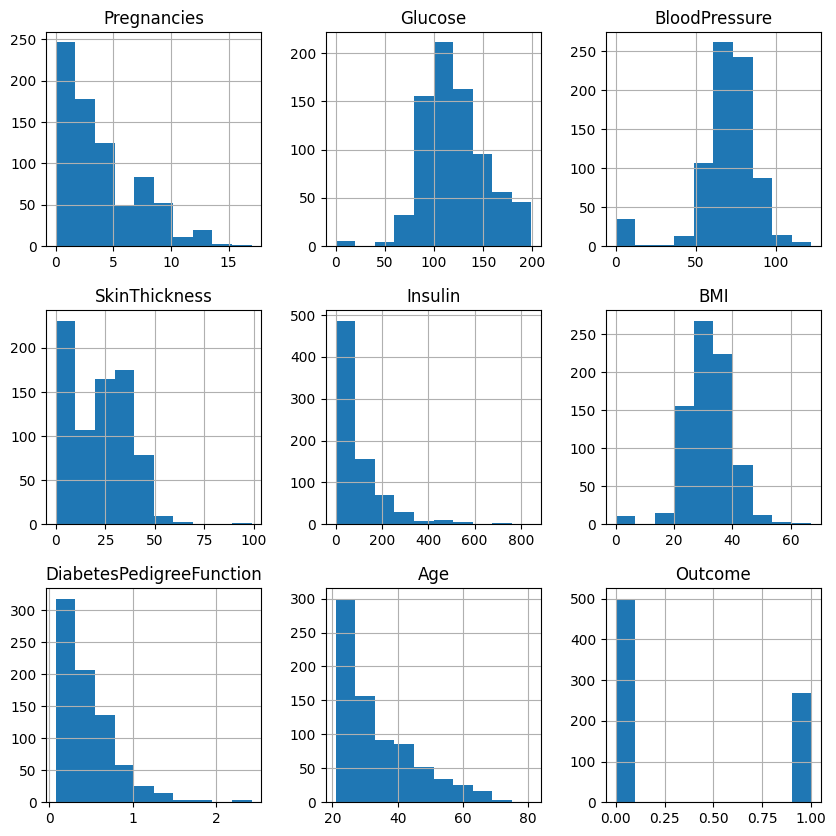

In [50]:
numerical_features = list(df.columns)
print(numerical_features)

df[numerical_features].hist(bins=10, figsize=(10, 10))
plt.savefig('Histogram plots')
plt.show()


<Axes: xlabel='Pregnancies'>

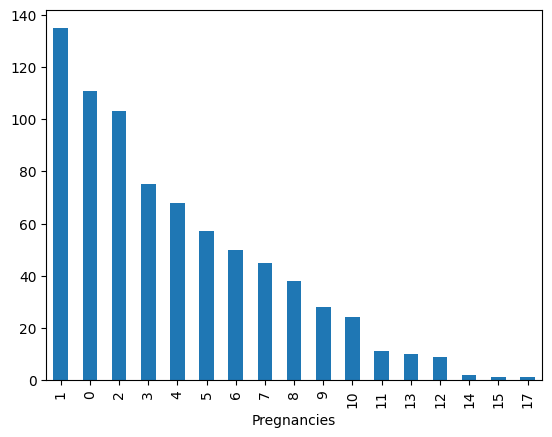

In [51]:
df['Pregnancies'].value_counts().plot(kind='bar')

<Axes: >

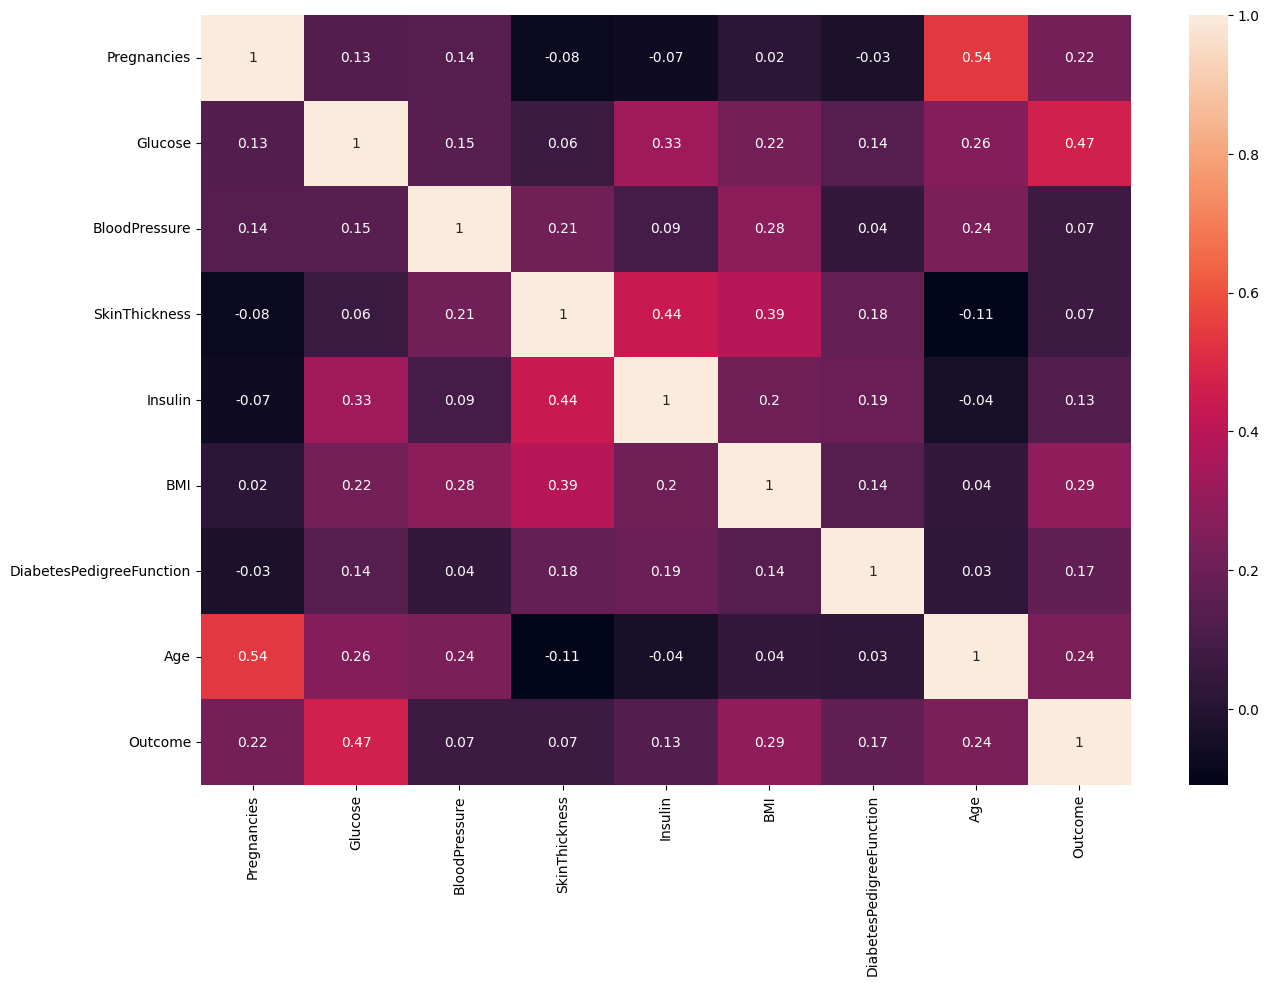

In [52]:
corr = df.corr(numeric_only=True).round(2)
plt.figure(figsize = (15,10))
sns.heatmap(corr, annot = True)

In [53]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [54]:
exclude_cols = ['Pregnancies', 'Outcome']

# Select columns to process (all except excluded ones)
cols_to_fix = [col for col in df.columns if col not in exclude_cols]

for col in cols_to_fix:
    if (df[col] == 0).any():  # only if column has 0
        median_value = df.loc[df[col] != 0, col].median()
        df.loc[df[col] == 0, col] = median_value

df.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,125,33.6,0.627,50,1
1,1,85,66,29,125,26.6,0.351,31,0
2,8,183,64,29,125,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,29,125,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,72,29,125,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,29,125,32.3,0.232,54,1


In [55]:
X = df.drop('Outcome', axis = 1)
print(X)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35      125  33.6   
1              1       85             66             29      125  26.6   
2              8      183             64             29      125  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27      125  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60             29      125  30.1   
767            1       93             70             31      125  30.4   

     DiabetesPedigreeFunction  Age  
0                       0.627   50  
1                       0.351   31  


In [56]:
y = df['Outcome']
print(y)

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64


In [57]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)
print("X_train Shape : ", X_train.shape)
print("X_test Shape  : ", X_test.shape)
print("y_train Shape : ", y_train.shape)
print("y_test Shape  : ", y_test.shape)

X_train Shape :  (614, 8)
X_test Shape  :  (154, 8)
y_train Shape :  (614,)
y_test Shape  :  (154,)


In [58]:
scaler = preprocessing.MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

LOGISTIC REGRESSION CLASSIFIER

In [59]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

ylrpredict = lr.predict(X_test)

cm_lr = confusion_matrix(y_test, ylrpredict)
print(cm_lr)

[[98  9]
 [20 27]]


In [60]:
cl_report_lr = classification_report(y_test, ylrpredict)
print(cl_report_lr)

ac_score_lr = accuracy_score(y_test, ylrpredict)
print(f"Accuracy Score: {ac_score_lr}")

f1_lr = f1_score(y_test, ylrpredict)
print(f'F1 Score: {f1_lr:.2f}')

              precision    recall  f1-score   support

           0       0.83      0.92      0.87       107
           1       0.75      0.57      0.65        47

    accuracy                           0.81       154
   macro avg       0.79      0.75      0.76       154
weighted avg       0.81      0.81      0.80       154

Accuracy Score: 0.8116883116883117
F1 Score: 0.65


RANDOM FOREST CLASSIFIER

In [ ]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
yrfpredict = rf.predict(X_test)

cm_rf = confusion_matrix(y_test, yrfpredict)
print(cm_rf)

[[94 13]
 [13 34]]


In [62]:
cl_report_rf = classification_report(y_test, yrfpredict)
print(cl_report_rf)

ac_score_rf = accuracy_score(y_test, yrfpredict)
print(f"Accuracy Score: {ac_score_rf}")

f1_rf = f1_score(y_test, yrfpredict)
print(f'F1 Score: {f1_rf:.2f}')

              precision    recall  f1-score   support

           0       0.88      0.88      0.88       107
           1       0.72      0.72      0.72        47

    accuracy                           0.83       154
   macro avg       0.80      0.80      0.80       154
weighted avg       0.83      0.83      0.83       154

Accuracy Score: 0.8311688311688312
F1 Score: 0.72


DECISION TREE CLASSIFIER

In [63]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
ydtpredict = dt.predict(X_test)

cm_dt = confusion_matrix(y_test, ydtpredict)
print(cm_dt)

[[86 21]
 [18 29]]


In [64]:
cl_report_dt = classification_report(y_test, ydtpredict)
print(cl_report_dt)

ac_score_dt = accuracy_score(y_test, ydtpredict)
print(f"Accuracy Score: {ac_score_dt}")

f1_dt = f1_score(y_test, ydtpredict)
print(f'F1 Score: {f1_dt:.2f}')

              precision    recall  f1-score   support

           0       0.83      0.80      0.82       107
           1       0.58      0.62      0.60        47

    accuracy                           0.75       154
   macro avg       0.70      0.71      0.71       154
weighted avg       0.75      0.75      0.75       154

Accuracy Score: 0.7467532467532467
F1 Score: 0.60


KNN CLASSIFIER

In [65]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
yknnpredict = knn.predict(X_test)

cm_knn = confusion_matrix(y_test, yknnpredict)
print(cm_knn)

[[89 18]
 [16 31]]


In [66]:
cl_report_knn = classification_report(y_test, yknnpredict)
print(cl_report_knn)

ac_score_knn = accuracy_score(y_test, yknnpredict)
print(f"Accuracy Score: {ac_score_knn}")

f1_knn = f1_score(y_test, yknnpredict)
print(f'F1 Score: {f1_knn:.2f}')

              precision    recall  f1-score   support

           0       0.85      0.83      0.84       107
           1       0.63      0.66      0.65        47

    accuracy                           0.78       154
   macro avg       0.74      0.75      0.74       154
weighted avg       0.78      0.78      0.78       154

Accuracy Score: 0.7792207792207793
F1 Score: 0.65


X GRADIENT BOOST CLASSIFIER

In [67]:
xgb = GradientBoostingClassifier()
xgb.fit(X_train, y_train)
ygbpredict = xgb.predict(X_test)

cm_xgb = confusion_matrix(y_test, ygbpredict)
print(cm_xgb)

[[94 13]
 [14 33]]


In [68]:
cl_report_xgb = classification_report(y_test, ygbpredict)
print(cl_report_xgb)

ac_score_xgb = accuracy_score(y_test, ygbpredict)
print(f"Accuracy Score: {ac_score_xgb}")

f1_xgb = f1_score(y_test, ygbpredict)
print(f'F1 Score: {f1_xgb:.2f}')

              precision    recall  f1-score   support

           0       0.87      0.88      0.87       107
           1       0.72      0.70      0.71        47

    accuracy                           0.82       154
   macro avg       0.79      0.79      0.79       154
weighted avg       0.82      0.82      0.82       154

Accuracy Score: 0.8246753246753247
F1 Score: 0.71


SUPPORT VECTOR MACHINE CLASSIFIER

In [69]:
svm = SVC()
svm.fit(X_train, y_train)
ysvmpredict = svm.predict(X_test)

cm_svm = confusion_matrix(y_test, ysvmpredict)
print(cm_svm)

[[96 11]
 [24 23]]


In [70]:
cl_report_svm = classification_report(y_test, ysvmpredict)
print(cl_report_svm)

ac_score_svm = accuracy_score(y_test, ysvmpredict)
print(f"Accuracy Score: {ac_score_svm}")

f1_svm = f1_score(y_test, ysvmpredict)
print(f'F1 Score: {f1_svm:.2f}')

              precision    recall  f1-score   support

           0       0.80      0.90      0.85       107
           1       0.68      0.49      0.57        47

    accuracy                           0.77       154
   macro avg       0.74      0.69      0.71       154
weighted avg       0.76      0.77      0.76       154

Accuracy Score: 0.7727272727272727
F1 Score: 0.57


In [71]:
models = ['Logistic Regression', 'Decision Tree', 'K Nearest Neighbour', 'Random Forest', 'Gradient Boosting', 'Support Vector Machine']
F1_Score = [f1_lr, f1_dt, f1_knn, f1_rf, f1_xgb, f1_svm]
compare_models = pd.DataFrame({'Algorithms': models, 'F1 Score': F1_Score})
compare_models.sort_values(by = 'F1 Score', ascending=False)

,Algorithms,F1 Score
3,Random Forest,0.723404
4,Gradient Boosting,0.709677
0,Logistic Regression,0.650602
2,K Nearest Neighbour,0.645833
1,Decision Tree,0.597938
5,Support Vector Machine,0.567901
